# 04_Math_Intuition.ipynb

---

# Final Formula(s)

Unlike Linear Regression or Logistic Regression, **KNN does not have one single prediction formula**.

Instead, KNN mainly relies on:

1. **Distance Formula** (to find the nearest neighbors)
2. **Voting** (for classification)
3. **Average** (for regression)

So the mathematics of KNN is centered around **measuring similarity**, not learning parameters.

---

## 1. Euclidean Distance (Most Common)

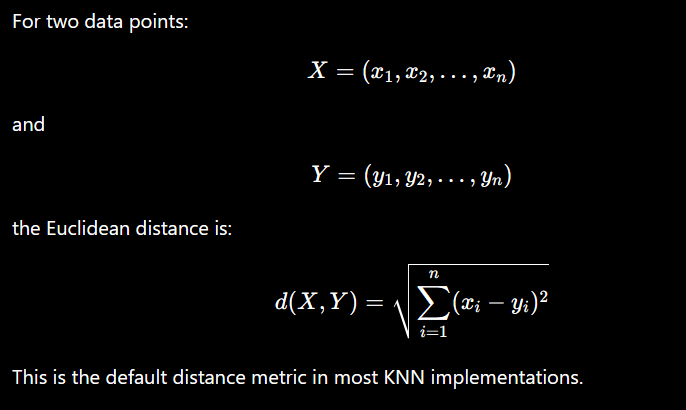

---

## 2. Manhattan Distance

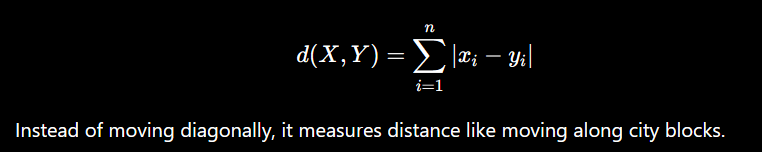

---

## 3. Minkowski Distance

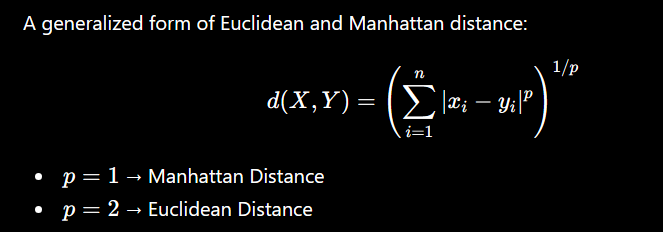

---

## 4. Classification Prediction

Suppose the K nearest neighbors are:

```text
Dog
Dog
Cat
Dog
Cat
```

Prediction:

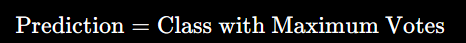

There is no algebraic formula—it's simply majority voting.

---

## 5. Regression Prediction

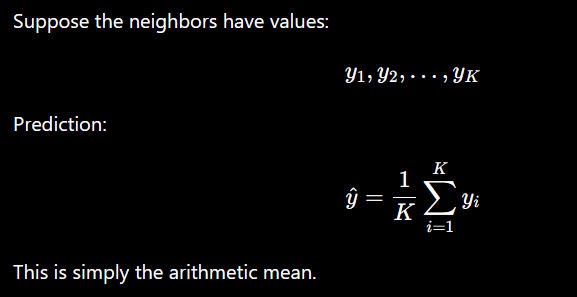

---

# Meaning of Every Symbol

## Euclidean Distance

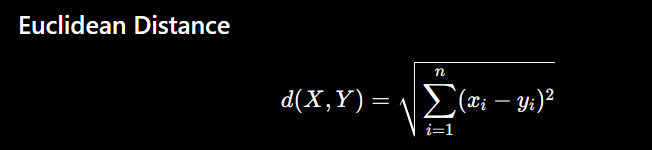

| Symbol   | Meaning                     |
| -------- | --------------------------- |
| (d(X,Y)) | Distance between two points |
| (X)      | First data point            |
| (Y)      | Second data point           |
| (x_i)    | ith feature of first point  |
| (y_i)    | ith feature of second point |
| (n)      | Number of features          |
| (\Sigma) | Sum over all features       |

---

## Regression Formula

[
\hat y=\frac1K\sum_{i=1}^{K}y_i
]

| Symbol   | Meaning                |
| -------- | ---------------------- |
| (\hat y) | Predicted value        |
| (K)      | Number of neighbors    |
| (y_i)    | Output of ith neighbor |

---

# Why This Formula Works

The intuition is:

> **Nearby points are more likely to have similar outputs than distant points.**

Suppose we want to predict the price of a house.

Training data:

| Size | Price |
| ---- | ----- |
| 1000 | 50L   |
| 1020 | 51L   |
| 1050 | 52L   |
| 3000 | 2Cr   |

Predict for:

```text
1015 sq.ft
```

The nearby houses (1000 and 1020) are much more informative than the 3000 sq.ft house.

Using distances lets us identify the most relevant examples.

---

## Why Square the Differences?

Example:

Difference:

```text
-3
```

Without squaring:

```text
-3
```

Another difference:

```text
3
```

If we simply add:

```text
3 + (-3)=0
```

The differences cancel each other, which is undesirable.

Squaring makes all differences non-negative:

```text
(-3)² = 9
3² = 9
```

This prevents cancellation and emphasizes larger differences.

---

## Why Take the Square Root?

Suppose:

Squared distance:

```text
25
```

Taking the square root gives:

```text
5
```

This converts the value back to the original units.

Without the square root, the ordering of distances would remain the same, but the units would be squared (e.g., cm² instead of cm).

---

# Geometry Intuition

Imagine a 2D graph.

```text
           Y

8                ● B

6

4

2     ● A

0________________________ X
```

Point A:

```text
(2,2)
```

Point B:

```text
(6,8)
```

Euclidean distance:

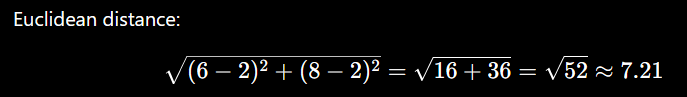

This is simply the length of the straight line connecting the two points.

---

## In Higher Dimensions

With three features:

```text
Height

Weight

Age
```

Each sample becomes a point in **3D space**.

With ten features, each sample exists in **10-dimensional space**.

Although we cannot visualize higher dimensions, the same distance formula still applies.

---

# Optimization Intuition

Unlike many ML algorithms, **KNN does not optimize any objective function**.

Compare:

### Linear Regression

Optimizes:

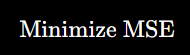

using Gradient Descent or a closed-form solution.

---

### Logistic Regression

Optimizes:

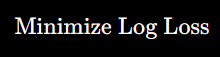

using optimization algorithms.

---

### KNN

Optimizes **nothing**.

There are:

* No weights
* No coefficients
* No loss function
* No gradient
* No epochs

Training simply stores the dataset.

This is why KNN is called a **Lazy Learner**.

---

# Hyperparameter Effect

The main hyperparameters are:

---

## 1. K (Number of Neighbors)

This is the most important hyperparameter.

### Small K

Example:

```text
K = 1
```

Characteristics:

* Very flexible
* Complex decision boundary
* Sensitive to noise
* High variance
* Low bias

---

### Large K

Example:

```text
K = 15
```

Characteristics:

* Smooth decision boundary
* Less affected by noise
* Higher bias
* Lower variance

---

## Example

Training points:

```text
○ ○ ○

      ?

● ● ●
```

### K = 1

Prediction depends only on the closest point.

---

### K = 7

Prediction depends on many nearby points.

The boundary becomes much smoother.

---

## 2. Distance Metric

Different distance metrics can change which neighbors are considered "nearest."

Common choices:

* Euclidean
* Manhattan
* Minkowski
* Chebyshev

Different metrics may produce different predictions, especially when feature distributions differ.

---

## 3. Weighting

### Uniform Weights

Each neighbor contributes equally.

Example:

```text
Neighbor 1 → 1 vote

Neighbor 2 → 1 vote
```

---

### Distance Weights

Closer neighbors contribute more.

Example:

```text
Distance 1 → Higher weight

Distance 10 → Lower weight
```

This often improves performance when closer samples are more reliable.

---

# Time Complexity

Assume:

* (n) = number of training samples
* (d) = number of features

---

## Training

Training only stores the data.

Time Complexity:

[
O(1)
]

or, if you include storing the data,

[
O(n)
]

There is no model fitting.

---

## Prediction

For one query point:

Compute distances to all training samples:

[
O(n \times d)
]

Then find the nearest neighbors.

If distances are sorted:

[
O(n\log n)
]

Overall (naive implementation):

[
O(n \times d + n\log n)
]

In practice, optimized implementations can avoid fully sorting all distances.

---

# Space Complexity

The entire training dataset must be stored.

Memory required:

[
O(n \times d)
]

where:

* (n) = number of training samples
* (d) = number of features

Unlike Linear Regression, KNN cannot discard the training data after training.

---

# Key Takeaways

* KNN is based on **distance calculations**, not parameter learning.
* The **Euclidean Distance** is the most commonly used distance metric, but others such as Manhattan and Minkowski are also available.
* For **classification**, KNN predicts using **majority voting**.
* For **regression**, it predicts using the **mean (or weighted mean)** of the K nearest neighbors.
* KNN has **no optimization process**, **no loss function**, and **no gradient descent**.
* The most important hyperparameters are:

  * **K (number of neighbors)**
  * **Distance metric**
  * **Weighting scheme**
* Training is extremely fast because it only stores the data, while prediction is computationally expensive because it must compare the query point to the stored training samples.